In [ ]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset,DataLoader
import torch.optim as optim
import torch.nn as nn
import matplotlib.pyplot as plt


In [ ]:
device = torch.device('cuda'if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# New section

In [ ]:
import kagglehub
path = kagglehub.dataset_download("zalando-research/fashionmnist")

Using Colab cache for faster access to the 'fashionmnist' dataset.


In [ ]:
torch.manual_seed(42)

In [ ]:
import pandas as pd

df = pd.read_csv('/kaggle/input/fashionmnist/fashion-mnist_test.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df.columns

Index(['label', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6',
       'pixel7', 'pixel8', 'pixel9',
       ...
       'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779', 'pixel780',
       'pixel781', 'pixel782', 'pixel783', 'pixel784'],
      dtype='object', length=785)

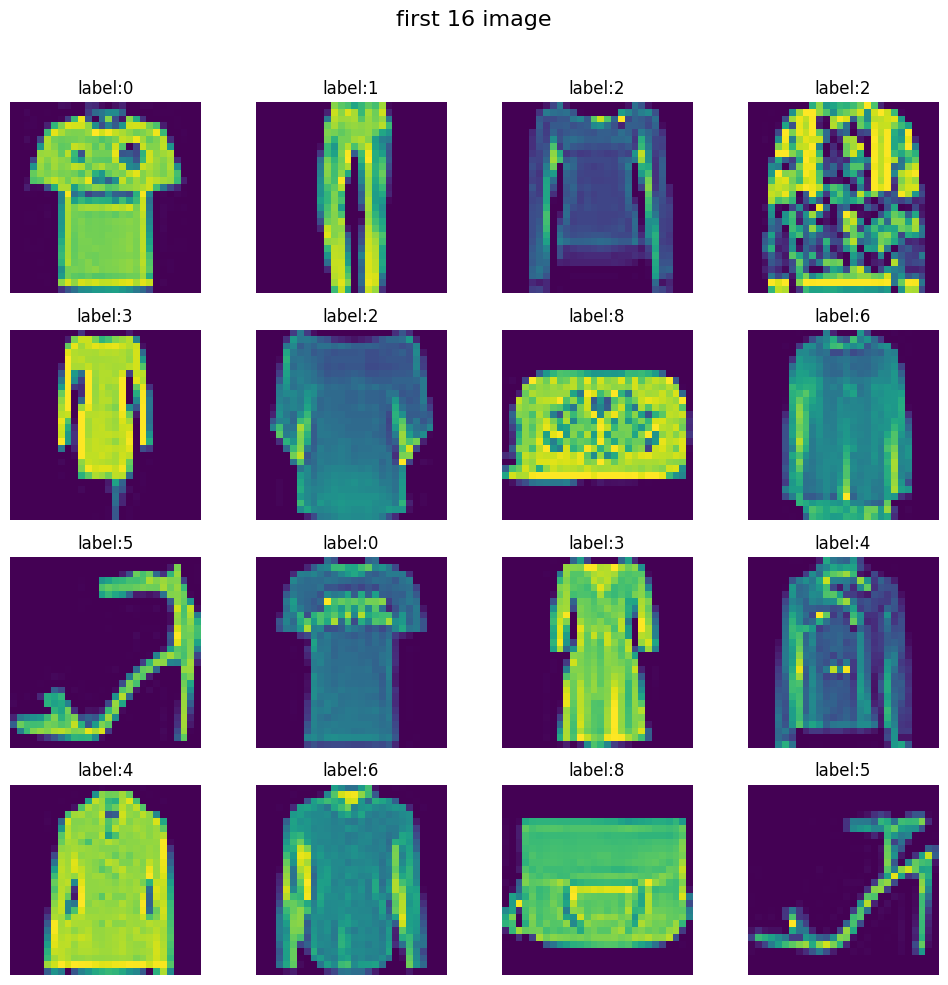

In [ ]:
fig,axes = plt.subplots(4,4,figsize=(10,10))
fig.suptitle('first 16 image',fontsize=16)

for i,ax in enumerate(axes.flat):
  img = df.iloc[i,1:].values.reshape(28,28)
  ax.imshow(img)
  ax.axis('off')
  ax.set_title(f"label:{df.iloc[i,0]}")

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

In [ ]:
X = pd.read_csv('/kaggle/input/fashionmnist/fashion-mnist_train.csv')
y = pd.read_csv('/kaggle/input/fashionmnist/fashion-mnist_test.csv')

In [ ]:
X.iloc[1]

,1
label,9
pixel1,0
pixel2,0
pixel3,0
pixel4,0
...,...
pixel780,0
pixel781,0
pixel782,0
pixel783,0


In [ ]:
X.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
y.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train = X.iloc[:,1:]
y_train = X.iloc[:,0]
X_test = y.iloc[:,1:]
y_test = y.iloc[:,0]



In [ ]:
X_test.columns

Index(['pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6', 'pixel7',
       'pixel8', 'pixel9', 'pixel10',
       ...
       'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779', 'pixel780',
       'pixel781', 'pixel782', 'pixel783', 'pixel784'],
      dtype='object', length=784)

In [ ]:

# scale beacuse pixel avlue is lie between 0-255

X_train = X_train/255.0
X_test = X_test/255.0

In [ ]:
# custom dataset class
class CustomDataset(Dataset):

  def __init__(self,features,labels) :
    self.features = torch.tensor(features.values,dtype=torch.float32) # Convert DataFrame to numpy array
    self.labels = torch.tensor(labels.values,dtype=torch.long) # Convert Series to numpy array and fix typo

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index],self.labels[index]

In [ ]:
# create train_dataset object
train_dataset = CustomDataset(X_train,y_train)

In [ ]:
train_dataset[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0157, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.2431, 0.2392, 0.0824, 0.1137, 0.0902,
         0.2000, 0.5333, 0.2392, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

In [ ]:
test_dataset = CustomDataset(X_test,y_test)

In [ ]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=False)


In [ ]:
#define nn class

class MyNN(nn.Module):
  def __init__(self,num_features):

    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(num_features,128),
        # nn.BatchNorm1d(128),2nd code improve
        nn.ReLU(),
        # nn.Dropout(p=0.3) 1st update
        nn.Linear(128,64),
        # nn.BatchNorm1d(64), 2nd code improve
        nn.ReLU(), # Corrected from nn.ReLu() to nn.ReLU()
        # nn.Dropout(p=0.3) 1st update
        nn.Linear(64,10),
        # there softmax is implemented implicitely
        )

  def forward(self,x):
    return self.model(x)

In [ ]:
epochs= 50
learning_rate = 0.1


In [ ]:
from torch.optim import optimizer
# object
model = MyNN(X_train.shape[1])# here gpu
model = model.to(device)


#loss
criterion = nn.CrossEntropyLoss()
#optimizer
optimizer = optim.SGD(model.parameters(),lr=learning_rate,weight_decay=1e-4)#weught decay is regularization

In [ ]:
#train loop
for epoch in range(epochs):
  total_epoch_loss = 0
  for batch_features,batch_labels in train_loader:

    #step 3 gpu
    batch_features,batch_labels=batch_features.to(device),batch_labels.to(device)

    #forawrd
    outputs = model(batch_features)
    # claculate
    loss = criterion(outputs,batch_labels)

    #back pass
    optimizer.zero_grad()#clear the gradient
    loss.backward()
    #update
    optimizer.step()

    total_epoch_loss += loss.item()

  avg_total = total_epoch_loss/len(train_loader)
  print(f'epoch:{epoch+1},loss:{avg_total}')

epoch:1,loss:0.4865212971806526
epoch:2,loss:0.3712817894339561
epoch:3,loss:0.3383505693336328
epoch:4,loss:0.31505630451838174
epoch:5,loss:0.2969433170656363
epoch:6,loss:0.28345335661967597
epoch:7,loss:0.2746324568847815
epoch:8,loss:0.26313069324294724
epoch:9,loss:0.2522454428911209
epoch:10,loss:0.24624803173144658
epoch:11,loss:0.23737093731661638
epoch:12,loss:0.2302119636187951
epoch:13,loss:0.22694164895514649
epoch:14,loss:0.2176790361871322
epoch:15,loss:0.21227875745197136
epoch:16,loss:0.20857559649050236
epoch:17,loss:0.20775202572842438
epoch:18,loss:0.2013553096373876
epoch:19,loss:0.1991437259554863
epoch:20,loss:0.19390355671048165
epoch:21,loss:0.19160896239727734
epoch:22,loss:0.18724342324982088
epoch:23,loss:0.18296377421319485
epoch:24,loss:0.179571181230247
epoch:25,loss:0.17898229700823626
epoch:26,loss:0.1740390524228414
epoch:27,loss:0.1748688535640637
epoch:28,loss:0.17310197101930777
epoch:29,loss:0.168623668328921
epoch:30,loss:0.16676295305838187
epoch

In [ ]:
# set model to eval mode
model.eval()# becoz some working are different on train_time and test time

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [ ]:
import torch

total = 0
correct = 0
accuracy_list=[]
with torch.no_grad():
  for batch_features,batch_labels in test_loader:

    # move the data to gpu
    batch_features,batch_labels=batch_features.to(device),batch_labels.to(device)
    y_pred = model(batch_features)
    # Get the predicted class by finding the index with the maximum score
    predicted_classes = y_pred.argmax(dim=1)

    # Compare predicted classes with actual labels
    batch_accuracy = (predicted_classes == batch_labels).float().mean().item()
    accuracy_list.append(batch_accuracy)

overall_accuracy = sum(accuracy_list)/len(accuracy_list)
print(f'accuracy:{overall_accuracy:.4f}')

accuracy:0.8916


In [ ]:
# try on train data
import torch

total = 0
correct = 0
accuracy_list=[]
with torch.no_grad():
  for batch_features,batch_labels in train_loader:

    # move the data to gpu
    batch_features,batch_labels=batch_features.to(device),batch_labels.to(device)
    y_pred = model(batch_features)
    # Get the predicted class by finding the index with the maximum score
    predicted_classes = y_pred.argmax(dim=1)

    # Compare predicted classes with actual labels
    batch_accuracy = (predicted_classes == batch_labels).float().mean().item()
    accuracy_list.append(batch_accuracy)

overall_accuracy = sum(accuracy_list)/len(accuracy_list)
print(f'accuracy:{overall_accuracy:.4f}')

accuracy:0.9608


In [ ]:
len(test_loader)

313